# 03 — Feature Engineering and Selection

In [ ]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
# When notebooks are launched from notebooks/, move to repository root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
MODELS = PROJECT_ROOT / "models"

DATA_PROCESSED.mkdir(exist_ok=True, parents=True)
FIGURES.mkdir(exist_ok=True, parents=True)
MODELS.mkdir(exist_ok=True, parents=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

purchase_path = DATA_PROCESSED / "purchase_transactions.csv"
df = pd.read_csv(purchase_path, parse_dates=["InvoiceDate"])

df["Customer ID"] = pd.to_numeric(df["Customer ID"], errors="coerce")
df["TotalPrice"] = pd.to_numeric(df["TotalPrice"], errors="coerce")

df = df.dropna(subset=["Customer ID", "InvoiceDate"]).copy()
df["Customer ID"] = df["Customer ID"].astype(int)

print(df.shape)
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

(793609, 11)
2009-12-01 07:45:00 to 2011-12-09 12:50:00


## 1. Choose monthly prediction dates

In [ ]:
dates = pd.date_range(
    start=df["InvoiceDate"].min().normalize() + pd.offsets.MonthBegin(2),
    end=df["InvoiceDate"].max().normalize() - pd.Timedelta(days=31),
    freq="MS"
)
print("Prediction dates:", len(dates))
display(pd.DataFrame({"prediction_date": dates}))

Prediction dates: 22


,prediction_date
0,2010-02-01
1,2010-03-01
2,2010-04-01
3,2010-05-01
4,2010-06-01
5,2010-07-01
6,2010-08-01
7,2010-09-01
8,2010-10-01
9,2010-11-01


## 2. Build leakage-safe customer features

In [ ]:
def build_snapshot(transactions, prediction_date, lookback_days=180, horizon_days=30):
    past_start = prediction_date - pd.Timedelta(days=lookback_days)
    future_end = prediction_date + pd.Timedelta(days=horizon_days)

    past = transactions[
        (transactions["InvoiceDate"] < prediction_date) &
        (transactions["InvoiceDate"] >= past_start)
    ].copy()

    future = transactions[
        (transactions["InvoiceDate"] >= prediction_date) &
        (transactions["InvoiceDate"] < future_end)
    ][["Customer ID", "InvoiceDate"]].copy()

    if past.empty:
        return pd.DataFrame()

    grouped = past.groupby("Customer ID")

    feat = grouped.agg(
        RecencyDays=("InvoiceDate", lambda s: (prediction_date - s.max()).days),
        TransactionCount=("Invoice", "nunique"),
        PurchaseDays=("InvoiceDate", lambda s: s.dt.date.nunique()),
        TotalSpend=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        ActiveMonths=("InvoiceDate", lambda s: s.dt.to_period("M").nunique())
    ).reset_index()

    country = (
        past.sort_values("InvoiceDate")
            .drop_duplicates("Customer ID", keep="last")[["Customer ID", "Country"]]
    )
    feat = feat.merge(country, on="Customer ID", how="left")

    feat["AvgItemsPerTransaction"] = feat["TotalQuantity"] / feat["TransactionCount"].replace(0, np.nan)
    feat["PurchaseDaysPerMonth"] = feat["PurchaseDays"] / feat["ActiveMonths"].replace(0, np.nan)

    # Target: did this customer purchase in the next 30 days?
    buyers_next_30 = set(future["Customer ID"].dropna().astype(int).unique())
    feat["return_30d"] = feat["Customer ID"].isin(buyers_next_30).astype(int)
    feat["PredictionDate"] = prediction_date

    return feat

snapshots = []
for d in dates:
    snap = build_snapshot(df, d)
    if not snap.empty:
        snapshots.append(snap)

model_df = pd.concat(snapshots, ignore_index=True)

print("Customer-period dataset:", model_df.shape)
print(model_df["return_30d"].value_counts(normalize=True).rename("proportion"))
display(model_df.head())

Customer-period dataset: (61852, 14)
return_30d
0    0.725635
1    0.274365
Name: proportion, dtype: float64


,Customer ID,RecencyDays,TransactionCount,PurchaseDays,TotalSpend,AverageOrderValue,TotalQuantity,UniqueProducts,ActiveMonths,Country,AvgItemsPerTransaction,PurchaseDaysPerMonth,return_30d,PredictionDate
0,12346,9,9,5,203.50,22.611111,46,2,2,United Kingdom,5.111111,2.5,1,2010-02-01
1,12358,54,1,1,1429.83,84.107647,309,17,1,Austria,309.000000,1.0,0,2010-02-01
2,12359,46,2,2,838.89,24.673235,609,34,1,Cyprus,304.500000,2.0,0,2010-02-01
3,12361,5,1,1,109.20,15.600000,45,7,1,Belgium,45.000000,1.0,0,2010-02-01
4,12362,61,1,1,130.00,130.000000,1,1,1,Belgium,1.000000,1.0,0,2010-02-01


## 3. Check target construction

In [4]:
target_check = (
    model_df.groupby("PredictionDate")["return_30d"]
            .agg(["count", "mean", "sum"])
)
display(target_check)

,count,mean,sum
PredictionDate,,,
2010-02-01,1338,0.316891,424
2010-03-01,1712,0.348715,597
2010-04-01,2155,0.300696,648
2010-05-01,2449,0.290731,712
2010-06-01,2669,0.286999,766
2010-07-01,2757,0.262604,724
2010-08-01,2822,0.248405,701
2010-09-01,2831,0.297775,843
2010-10-01,2910,0.336426,979


## 4. Prepare numeric feature matrix for feature-selection experiments

In [5]:
numeric_features = [
    "RecencyDays",
    "TransactionCount",
    "PurchaseDays",
    "TotalSpend",
    "AverageOrderValue",
    "TotalQuantity",
    "UniqueProducts",
    "ActiveMonths",
    "AvgItemsPerTransaction",
    "PurchaseDaysPerMonth"
]

X_num = model_df[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = model_df["return_30d"].astype(int)

# Time-based split before supervised selection.
train_cut = model_df["PredictionDate"].quantile(0.70)
val_cut = model_df["PredictionDate"].quantile(0.85)

train_mask = model_df["PredictionDate"] < train_cut
val_mask = (model_df["PredictionDate"] >= train_cut) & (model_df["PredictionDate"] < val_cut)
test_mask = model_df["PredictionDate"] >= val_cut

print("Train:", train_mask.sum(), "Validation:", val_mask.sum(), "Test:", test_mask.sum())

Train: 41758 Validation: 8432 Test: 11662


## 5. Feature-selection experiment on training data only

In [6]:
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_num.loc[train_mask], y.loc[train_mask])

feature_scores = pd.DataFrame({
    "feature": numeric_features,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("F_score", ascending=False)

display(feature_scores)

,feature,F_score,p_value
7,ActiveMonths,6319.889835,0.000000e+00
2,PurchaseDays,5012.227992,0.000000e+00
1,TransactionCount,3894.545856,0.000000e+00
6,UniqueProducts,2511.605114,0.000000e+00
9,PurchaseDaysPerMonth,2494.632406,0.000000e+00
0,RecencyDays,1942.227585,0.000000e+00
3,TotalSpend,1243.557316,1.855764e-268
5,TotalQuantity,537.142049,4.403409e-118
4,AverageOrderValue,1.427563,2.321694e-01
8,AvgItemsPerTransaction,1.033410,3.093650e-01


## 6. PCA / dimensionality-reduction experiment

,component,explained_variance_ratio,cumulative_variance
0,1,0.451321,0.451321
1,2,0.186204,0.637525
2,3,0.103098,0.740623
3,4,0.080161,0.820784
4,5,0.058009,0.878793
5,6,0.050434,0.929227
6,7,0.044652,0.973879
7,8,0.011974,0.985853
8,9,0.010738,0.996591
9,10,0.003409,1.000000


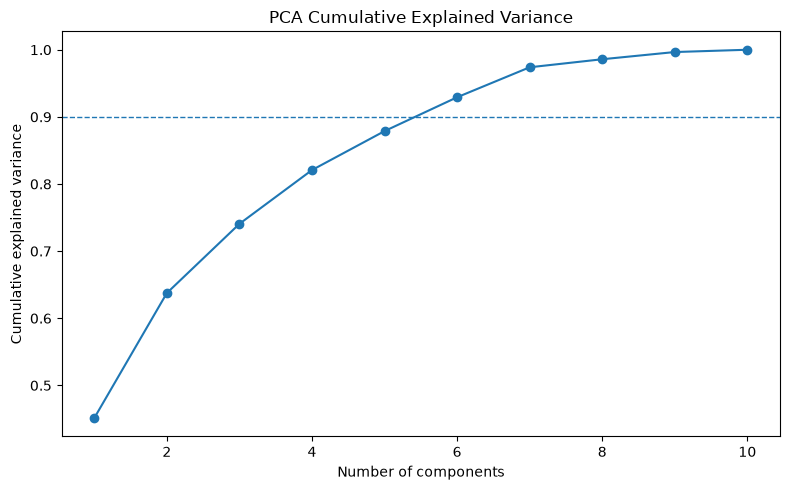

Components explaining >= 90% variance: 6


In [ ]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_num.loc[train_mask])

pca_full = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

pca_report = pd.DataFrame({
    "component": np.arange(1, len(cum_var)+1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": cum_var
})
display(pca_report)

plt.figure(figsize=(8, 5))
plt.plot(pca_report["component"], pca_report["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.tight_layout()
plt.savefig(FIGURES / "pca_explained_variance.png", dpi=160)
plt.show()

pca_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
print("Components explaining >= 90% variance:", pca_components_90)

## 7. Save the engineered modeling data

In [8]:
model_path = DATA_PROCESSED / "customer_modeling_data.csv"
model_df.to_csv(model_path, index=False)

feature_score_path = DATA_PROCESSED / "feature_selection_scores.csv"
feature_scores.to_csv(feature_score_path, index=False)

print("Saved:", model_path)
print("Saved:", feature_score_path)

Saved: C:\Sahir\CSE437\Project\data\processed\customer_modeling_data.csv
Saved: C:\Sahir\CSE437\Project\data\processed\feature_selection_scores.csv
